<a href="https://colab.research.google.com/github/braltoids0089/BIOMEDICINE/blob/main/HLA-I_Antigen_Processing_Machinery_Silencing_in_Melanoma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HLA-I Antigen-Processing-Machinery Silencing in Melanoma
### A Single-Cell Map of Immune Evasion

**Bernardo Ramos Raymundo, Ph.D.**

A reproducible, public-data single-cell analysis of how transcriptional silencing of the HLA class I
antigen-processing machinery (APM) marks an immune-evasive malignant state in melanoma, and which
microenvironmental signals associate with it. The workflow is **score → stratify → characterise →
nominate drivers → spatialise**, built on the Jerby-Arnon *et al.* (Cell, 2018) melanoma atlas.

> Scope: this is a methodological analysis on public data. It reproduces and extends published
> findings and is **hypothesis-generating**; it does not use private patient material, and the spatial
> section is an explicit demonstration of a transferable method.

## 1. Background and rationale

Cytotoxic CD8⁺ T cells recognise tumour cells through peptide–HLA class I complexes presented by the
antigen-processing and presentation machinery (APM): the HLA-I heavy chains, β2-microglobulin, the
peptide-loading complex (TAP1/2, tapasin, calreticulin), the immunoproteasome, and the master
transactivator **NLRC5**. Melanoma cells evade T-cell killing not only through genetic loss of these
components but through **coordinated transcriptional silencing** of the APM — yielding HLA-I-low cells
that escape recognition and contribute to immune-checkpoint-blockade (ICB) resistance. APM expression is
normally inducible by IFN-γ, so a blunted IFN-γ response is mechanistically coupled to APM-low states.

This analysis operationalises that biology at single-cell resolution. The Jerby-Arnon melanoma atlas is
a deliberate choice: the authors identified a malignant resistance program characterised by **low MHC-I
and IFN-γ-response expression, impaired antigen presentation, and a blunted response to IFN-γ**, driven
by a CDK4/6–E2F–MYC axis and marking immune-cold niches in situ. The HLA-I-low phenotype we want to study
is therefore already present in the data — letting us recover a landmark result and then push toward the
open question: *which microenvironmental cues associate with APM-silenced tumour cells?*

**Dataset.** Jerby-Arnon L, *et al.* A cancer cell program promotes T cell exclusion and resistance to
checkpoint blockade. *Cell* 175:984–997 (2018). GEO **GSE115978** — scRNA-seq of malignant and
non-malignant cells from 33 melanoma tumours (treatment-naïve and ICB-exposed). Processed expression and
cell annotations are public; raw reads are dbGaP-controlled and not required here.

## 2. Scope and Limitations

This analysis is a methodological demonstration using publicly available single-cell RNA-sequencing data from melanoma tumors. It aims to reproduce and extend findings related to HLA-I APM silencing as an immune evasion mechanism.

**Scope:**

*   **Hypothesis-Generating:** The primary goal is to generate testable hypotheses regarding the microenvironmental cues associated with APM-silenced tumor cells. It is not intended to provide definitive clinical conclusions.
*   **Public Data Utilization:** The entire analysis is based on the Jerby-Arnon *et al.* (Cell, 2018) melanoma atlas (GEO GSE115978).
*   **Methodological Demonstration:** The workflow showcases a reproducible pipeline for single-cell data analysis, from data acquisition to intercellular communication inference and a conceptual spatial analysis.

**Limitations:**

*   **Dataset Specificity:** Findings are specific to the Jerby-Arnon dataset and may not be universally generalizable to all melanoma cohorts or other cancer types without further validation.
*   **Absence of Private Patient Material:** The study does not involve private patient material, limiting direct clinical translational claims.
*   **Spatial Analysis is Conceptual:** The `squidpy` phase is a method demonstration using a skeleton code, as multiplexed-imaging data for this specific cohort is not available. Actual spatial insights would require integration with dedicated spatial transcriptomics or imaging data.
*   **Enrichment Challenges:** Pathway enrichment results (e.g., from `gseapy`) might not always yield highly significant terms, depending on the gene sets used and the magnitude of differential expression. This is a common challenge in transcriptomic analysis.
*   **Inferred Communication:** Ligand-receptor predictions from tools like `liana` are computational inferences and require experimental validation to confirm biological relevance.

## 3. Methodologies



## Computational Foundations & Workflow:

The workflow follows a structured sequence: **score → stratify → characterise → nominate drivers → spatialise**, implemented using state-of-the-art bioinformatics tools:

*   **Data Acquisition and Preprocessing:**
    *   Public data (GEO GSE115978) is acquired, ensuring reproducibility.
    *   `scanpy` is used for standard scRNA-seq preprocessing: quality control (filtering low-expressed genes/cells), normalization (log1p transformation), dimensionality reduction (PCA, UMAP), and nearest-neighbor graph construction.
    *   The use of `adata.raw` ensures that gene scoring and differential expression are performed on normalized (but not scaled) counts, preserving original expression magnitudes.
*   **Cell Type Identification:**
    *   Leverages existing `cell.types` annotations from the dataset.
    *   Confirms malignant cell identity using canonical melanocytic lineage markers (`MLANA`, `MITF`) and visualizes their expression on UMAP embeddings.
*   **APM Signature Scoring:**
    *   Quantifies APM activity in individual malignant cells using predefined gene sets (`APM_CORE`, `APM8`) via `sc.tl.score_genes`.
    *   An IFN-γ response gene set serves as a mechanistic positive control, validating the biological relevance of the APM scores.
*   **Cell Stratification:**
    *   Malignant cells are stratified into APM-low, APM-mid, and APM-high groups based on APM score terciles.
    *   Validation of these strata is performed by assessing their correlation with MITF-high (melanocytic) and AXL-high (dedifferentiated) programs.
*   **Differential Expression and Pathway Enrichment:**
    *   `sc.tl.rank_genes_groups` (Wilcoxon test) is applied to identify differentially expressed genes between APM-low and APM-high malignant cells.
    *   Results are visualized using a volcano plot.
    *   `gseapy` is used for gene set enrichment analysis (GSEA) on downregulated genes in APM-low cells, linking gene expression changes to biological pathways.
*   **Ligand-Receptor Communication Inference:**
    *   `liana` (LIgand-receptor ANalysis RAnk-aggregate) is employed to infer potential cell-cell communication pathways between microenvironmental cell types and the APM-stratified malignant cells.
    *   This step specifically targets interactions preferentially directed towards APM-low cells, aiming to nominate suppressive cues.
*   **Spatial Method Transfer (Conceptual):**
    *   A conceptual framework for integrating spatial transcriptomics data using `squidpy` is presented, demonstrating how to analyze neighborhood enrichment and co-occurrence of cell types in a spatial context.

## 4. Model Modules and Implementation

The computational framework is primarily implemented using the Python programming language, leveraging key libraries for single-cell data analysis, visualization, and specialized bioinformatics tasks:

**Core Libraries:**

*   **`scanpy` (`sc`):** The central library for single-cell RNA-seq data analysis. It handles data loading, quality control, normalization, dimensionality reduction (PCA, UMAP), clustering, gene scoring, and differential expression analysis. Its `AnnData` object is the primary data structure throughout the notebook.
*   **`anndata` (`ad`):** Provides the `AnnData` class, a flexible data structure designed to store and manage annotated data matrices, which is fundamental for single-cell analysis workflows.
*   **`pandas` (`pd`):** Used extensively for data manipulation, particularly for loading CSV files (expression matrices, cell annotations), managing `adata.obs` (cell metadata) and `adata.var` (gene metadata), and processing differential expression results.
*   **`numpy` (`np`):** Provides numerical computing capabilities, used for array operations, mathematical functions, and setting random seeds for reproducibility.
*   **`matplotlib.pyplot` (`plt`):** The primary library for creating static, interactive, and animated visualizations in Python, used for all custom plots (histograms, scatter plots, volcano plots, violin plots).
*   **`seaborn` (`sns`):** A high-level data visualization library based on `matplotlib` that provides a more aesthetically pleasing interface for creating informative statistical graphics, used for scatter plots, violin plots, and heatmaps.

**Specialized Bioinformatics Libraries:**

*   **`liana` (`li`):** (LIgand-receptor ANalysis RAnk-aggregate) A comprehensive framework for inferring cell-cell communication from single-cell transcriptomics data. It integrates various ligand-receptor inference methods and provides tools for their aggregation and visualization.
*   **`gseapy` (`gp`):** (Gene Set Enrichment Analysis in PYthon) A Python wrapper for the widely used GSEA and Enrichr tools, enabling convenient pathway and gene set enrichment analysis.
*   **`squidpy` (`sq`):** (Conceptual) A toolkit for the analysis and visualization of spatial molecular data, particularly designed for spatial transcriptomics. While not fully executed in this notebook, its skeleton code demonstrates its application for neighborhood enrichment and co-occurrence analysis in spatial contexts.

**Utility Libraries:**

*   **`os`:** Used for operating system interactions, such as creating directories (`os.makedirs`) and managing file paths.
*   **`urllib.request`:** Used for downloading files from URLs, specifically for acquiring the dataset from GEO.

## Phase 0 — Environment

All dependencies are pip-installable and Colab/Kaggle-friendly. Set a seed for reproducibility.

In [2]:
# If running on Colab/Kaggle, install dependencies (uncomment):
!pip -q install scanpy anndata liana decoupler gseapy squidpy leidenalg

import os
import urllib.request
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=110, frameon=False)
RNG = 0
np.random.seed(RNG)
print("scanpy", sc.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 969.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.9/563.9 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_4153/2852371242.py:14: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110, frameon=False)
/tmp/ipykernel_4153/2852371242.py:17: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


## Phase 1 — Data acquisition

Pull the processed TPM matrix and cell annotations directly from the GEO supplementary files. The matrix
is genes × cells; the annotation table carries cell-type calls and treatment group.

In [3]:
BASE = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE115nnn/GSE115978/suppl/"
FILES = {
    "tpm": "GSE115978_tpm.csv.gz",
    "ann": "GSE115978_cell.annotations.csv.gz",
}
os.makedirs("data", exist_ok=True)
for key, fname in FILES.items():
    dst = os.path.join("data", fname)
    if not os.path.exists(dst):
        print("downloading", fname, "...")
        urllib.request.urlretrieve(BASE + fname, dst)
    else:
        print("cached", fname)
print("done")

downloading GSE115978_tpm.csv.gz ...
downloading GSE115978_cell.annotations.csv.gz ...
done


In [4]:
# Load expression (genes x cells) and orient to cells x genes
tpm = pd.read_csv("data/GSE115978_tpm.csv.gz", index_col=0)
X = tpm.T  # cells x genes

# Load cell annotations; first column holds the cell barcode/id
ann = pd.read_csv("data/GSE115978_cell.annotations.csv.gz")
cell_col = ann.columns[0]
ann = ann.set_index(cell_col)

adata = ad.AnnData(
    X=X.values.astype("float32"),
    obs=pd.DataFrame(index=X.index.astype(str)),
    var=pd.DataFrame(index=X.columns.astype(str)),
)
ann.index = ann.index.astype(str)
adata.obs = adata.obs.join(ann.reindex(adata.obs_names))
print(adata)
print("annotation columns:", list(adata.obs.columns))

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'samples', 'cell.types', 'treatment.group', 'Cohort', 'no.of.genes', 'no.of.reads'
annotation columns: ['samples', 'cell.types', 'treatment.group', 'Cohort', 'no.of.genes', 'no.of.reads']


## Phase 2 — QC, normalisation and embedding

The deposited matrix is TPM-scale; log-transform if values are not already compressed, then build an
embedding from highly variable genes on a scaled copy (the unscaled log matrix is retained for scoring
and differential expression).

In [5]:
# Light QC: drop cells with very few detected genes
sc.pp.filter_genes(adata, min_cells=3)
n_genes = (adata.X > 0).sum(1)
adata.obs["n_genes"] = np.asarray(n_genes).ravel()
adata = adata[adata.obs["n_genes"] >= 500].copy()

# Log-transform if the data still looks like linear TPM
if float(adata.X.max()) > 50:
    sc.pp.log1p(adata)
adata.raw = adata  # log-normalised matrix kept for scoring / DE

# Embedding on HVGs (scaled copy)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
emb = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(emb, max_value=10)
sc.tl.pca(emb, n_comps=30, random_state=RNG)
sc.pp.neighbors(emb, n_neighbors=15, random_state=RNG)
sc.tl.umap(emb, random_state=RNG)
adata.obsm["X_umap"] = emb.obsm["X_umap"]
print("embedded", adata.n_obs, "cells")

embedded 7186 cells


## Phase 3 — Identify the malignant compartment

Use the published cell-type calls and confirm the malignant cells with melanocytic lineage markers. In
this dataset malignant cells are labelled `Mal`.

cell-type column: cell.types
cell.types
Mal           2018
T.CD8         1759
T.CD4          856
B.cell         818
T.cell         706
Macrophage     420
?              307
CAF            106
Endo.          104
NK              92
Name: count, dtype: int64


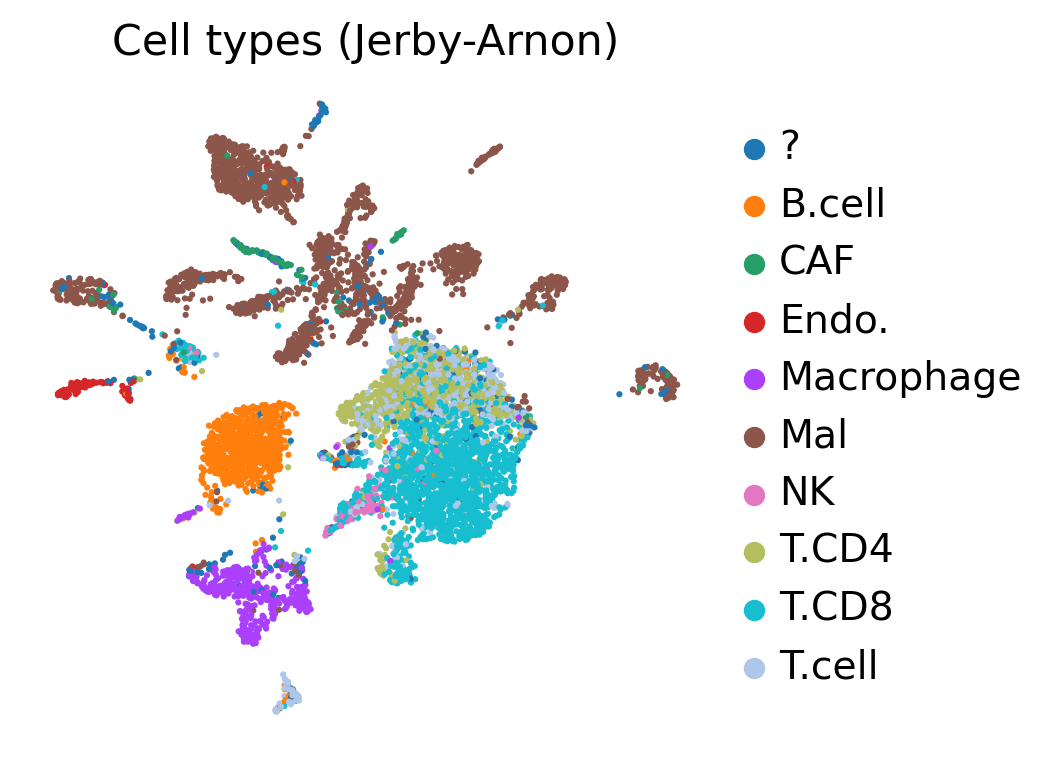

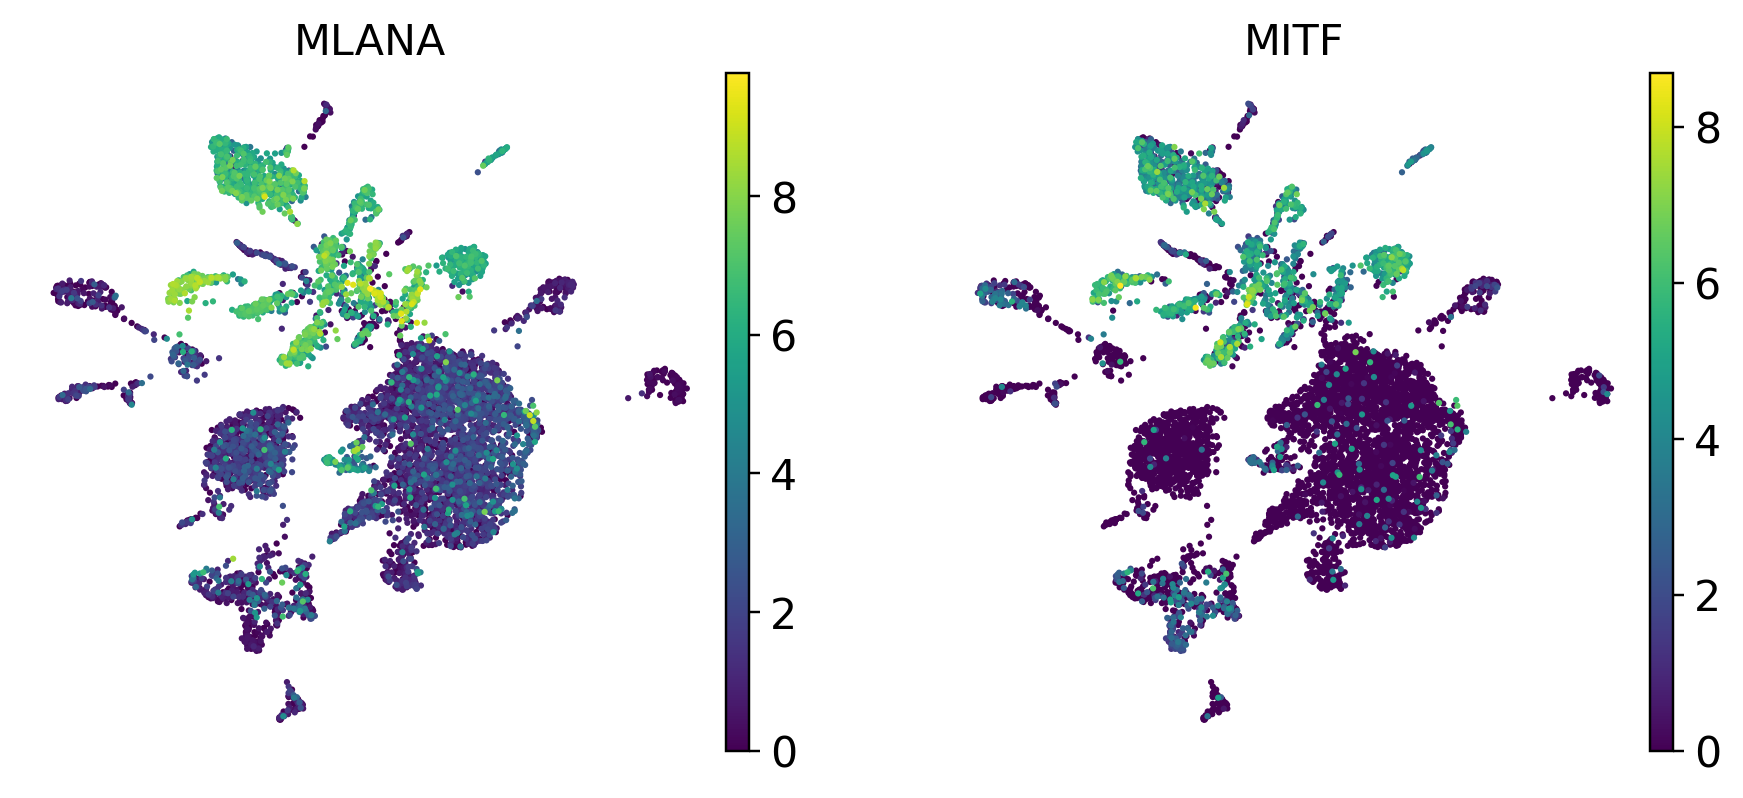

malignant cells: 2018


In [9]:
# Locate the cell-type column robustly
ct_col = next((c for c in adata.obs.columns
               if c.lower().replace(".", "").replace("_", "") in
               ("celltype", "celltypes", "type")), None)
print("cell-type column:", ct_col)
print(adata.obs[ct_col].value_counts())

sc.pl.umap(adata, color=ct_col, title="Cell types (Jerby-Arnon)", show=True)

# Confirm malignant identity with lineage markers
# The previous loop added gene expression to adata.obs, causing a conflict with adata.var_names
# when plotting. sc.pl.umap can directly use gene names from adata.var_names.
# For robustness, ensure MLANA and MITF are not in adata.obs.columns if they were added previously.
genes_to_check_and_remove = ["MLANA", "MITF"]
for g in genes_to_check_and_remove:
    if g in adata.obs.columns:
        del adata.obs[g]
# The original code that added these genes to adata.obs was commented out:
# for g in ["MLANA", "PMEL", "MITF", "TYR"]:
#     if g in adata.raw.var_names:
#         adata.obs[g] = np.asarray(adata.raw[:, g].X).ravel()

genes_to_plot = [g for g in ["MLANA", "MITF"] if g in adata.raw.var_names]
if genes_to_plot:
    sc.pl.umap(adata, color=genes_to_plot, show=True)
else:
    print("Warning: None of the specified genes (MLANA, MITF) were found in adata.raw.var_names.")

MAL_LABEL = "Mal"
mal = adata[adata.obs[ct_col] == MAL_LABEL].copy()
print("malignant cells:", mal.n_obs)

## Phase 4 — Score the HLA-I APM signature per malignant cell

Two complementary scores: a mechanistic APM gene set, and a published 8-gene APM score
(B2M, CALR, NLRC5, PSMB9, PSME1, PSME3, RFX5, HSP90AB1) shown to track checkpoint-blockade outcomes.
An IFN-γ-response score serves as the mechanistic axis and positive control, since APM is IFN-inducible.

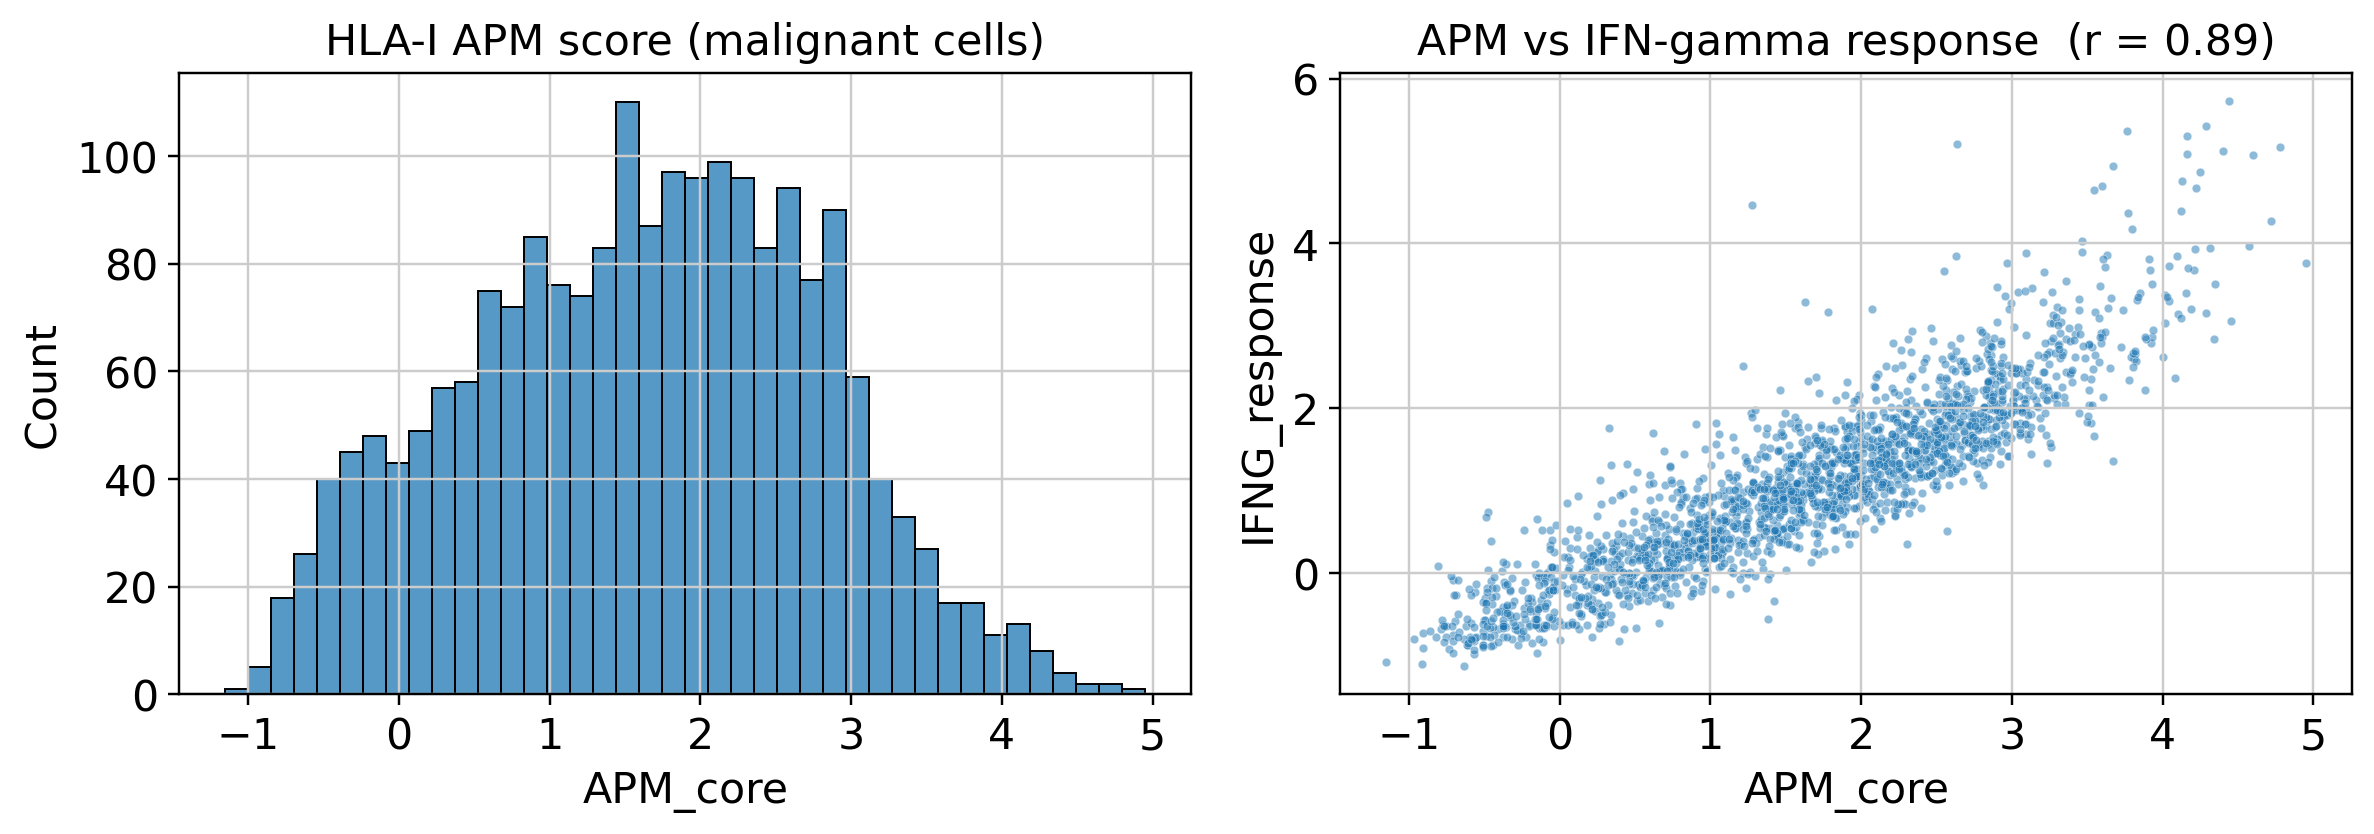

In [10]:
APM_CORE = ["HLA-A", "HLA-B", "HLA-C", "B2M",
            "TAP1", "TAP2", "TAPBP", "TAPBPL", "CALR", "CANX", "PDIA3",
            "PSMB8", "PSMB9", "PSMB10", "PSME1", "PSME2",
            "NLRC5", "RFX5"]
APM8 = ["B2M", "CALR", "NLRC5", "PSMB9", "PSME1", "PSME3", "RFX5", "HSP90AB1"]
IFNG_RESPONSE = ["STAT1", "IRF1", "GBP1", "GBP2", "CXCL9", "CXCL10", "CXCL11",
                 "IDO1", "WARS", "PSMB9", "TAP1", "HLA-A", "HLA-B", "B2M", "JAK2"]

def present(genes):
    return [g for g in genes if g in mal.raw.var_names]

sc.tl.score_genes(mal, present(APM_CORE), score_name="APM_core", use_raw=True)
sc.tl.score_genes(mal, present(APM8), score_name="APM8", use_raw=True)
sc.tl.score_genes(mal, present(IFNG_RESPONSE), score_name="IFNG_response", use_raw=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(mal.obs["APM_core"], bins=40, ax=ax[0]); ax[0].set_title("HLA-I APM score (malignant cells)")
sns.scatterplot(x="APM_core", y="IFNG_response", data=mal.obs, s=8, alpha=0.5, ax=ax[1])
r = np.corrcoef(mal.obs["APM_core"], mal.obs["IFNG_response"])[0, 1]
ax[1].set_title(f"APM vs IFN-gamma response  (r = {r:.2f})")
plt.tight_layout(); plt.show()

## Phase 5 — Stratify APM-high vs APM-low malignant cells

Split malignant cells by APM-score terciles. As a validation that the strata are biologically meaningful,
contrast them along the MITF-high / AXL-high dedifferentiation axis — APM-low cells are expected to skew
dedifferentiated/mesenchymal, consistent with the published resistance state.

> *To reproduce the Jerby-Arnon immune-resistance program exactly, paste its gene list from the paper's
> Supplementary Table into `IR_PROGRAM` below and score it; it should be anti-correlated with APM.*

APM_stratum
APM_low     673
APM_high    673
APM_mid     672
Name: count, dtype: int64


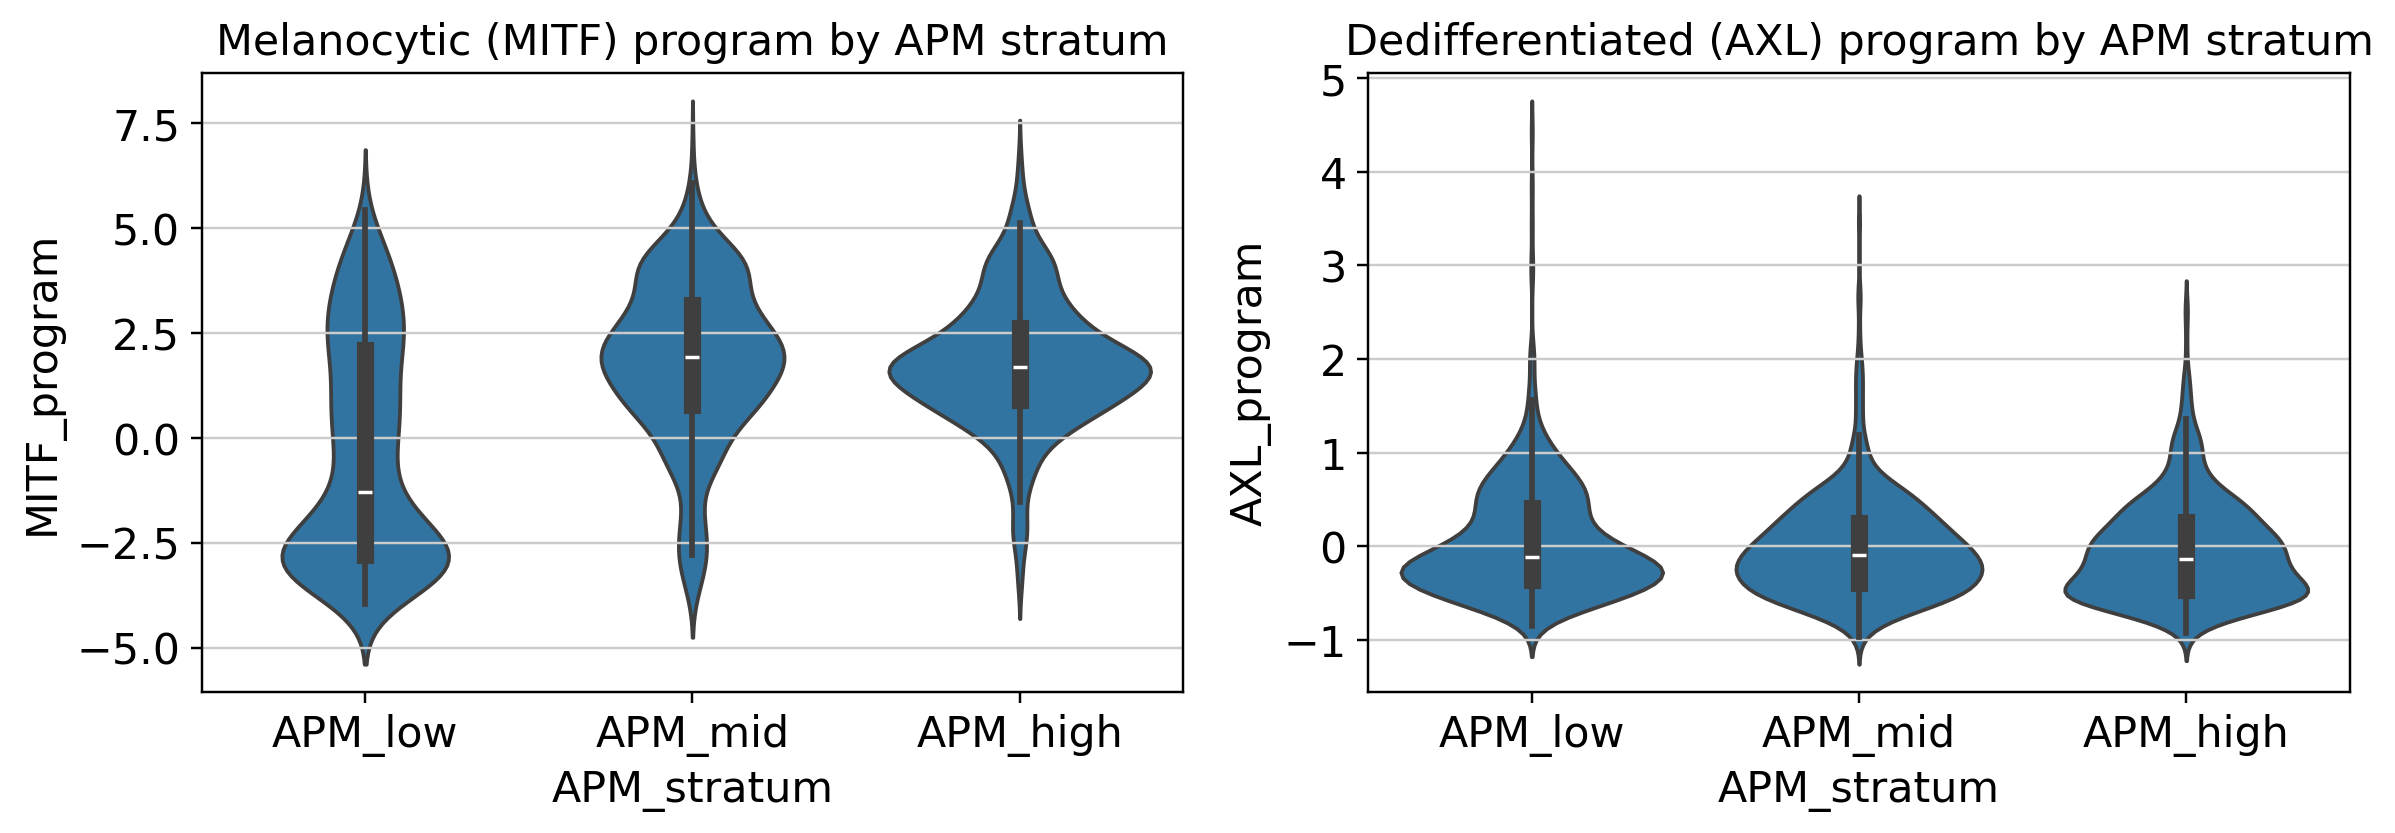

In [11]:
q1, q2 = mal.obs["APM_core"].quantile([1/3, 2/3])
mal.obs["APM_stratum"] = pd.cut(
    mal.obs["APM_core"], bins=[-np.inf, q1, q2, np.inf],
    labels=["APM_low", "APM_mid", "APM_high"])
print(mal.obs["APM_stratum"].value_counts())

MITF_PROGRAM = ["MITF", "MLANA", "PMEL", "TYR", "DCT", "TYRP1"]
AXL_PROGRAM = ["AXL", "NGFR", "WNT5A", "EGFR", "TGFBI", "FN1"]
sc.tl.score_genes(mal, [g for g in MITF_PROGRAM if g in mal.raw.var_names],
                  score_name="MITF_program", use_raw=True)
sc.tl.score_genes(mal, [g for g in AXL_PROGRAM if g in mal.raw.var_names],
                  score_name="AXL_program", use_raw=True)

# IR_PROGRAM = [...]  # paste published immune-resistance program genes to reproduce exactly
# sc.tl.score_genes(mal, [g for g in IR_PROGRAM if g in mal.raw.var_names],
#                   score_name="IR_program", use_raw=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.violinplot(x="APM_stratum", y="MITF_program", data=mal.obs, ax=ax[0])
ax[0].set_title("Melanocytic (MITF) program by APM stratum")
sns.violinplot(x="APM_stratum", y="AXL_program", data=mal.obs, ax=ax[1])
ax[1].set_title("Dedifferentiated (AXL) program by APM stratum")
plt.tight_layout(); plt.show()

## Phase 6 — Differential program characterisation

Differential expression between APM-low and APM-high malignant cells, followed by pathway enrichment.
Expect antigen-presentation and IFN-γ-response terms depleted in APM-low cells, with a
dedifferentiation/proliferation signature enriched.

   names    scores  logfoldchanges         pvals     pvals_adj
    RPS6 22.761221        2.524045 1.111077e-114 1.472308e-111
    RPL6 22.372950        2.242454 7.220219e-111 7.745233e-108
   RPL26 22.259630        2.555377 9.099503e-110 9.317478e-107
   RPS4X 21.638479        1.809719 7.803556e-104 7.031628e-101
  RPL18A 21.621298        2.795877 1.132458e-103 9.811881e-101
    RPS5 21.548721        2.821749 5.442973e-103 4.379066e-100
   UBA52 21.292000        2.146588 1.346571e-100  1.011140e-97
    RPS7 21.138851        2.164639  3.494835e-99  2.460254e-96
  RPS27A 21.126650        1.711868  4.525422e-99  3.089218e-96
   RPLP0 21.013681        2.289748  4.917145e-98  3.164815e-95
    RPS8 20.928482        1.905049  2.947381e-97  1.794477e-94
   RPS19 20.759624        2.789272  1.003475e-95  5.651319e-93
   RPS23 20.677370        1.814835  5.537873e-95  3.042724e-92
RPL13AP5 20.639082        2.553146  1.223625e-94  6.562997e-92
   RPS15 20.612295        2.112405  2.128913e-94  1.115

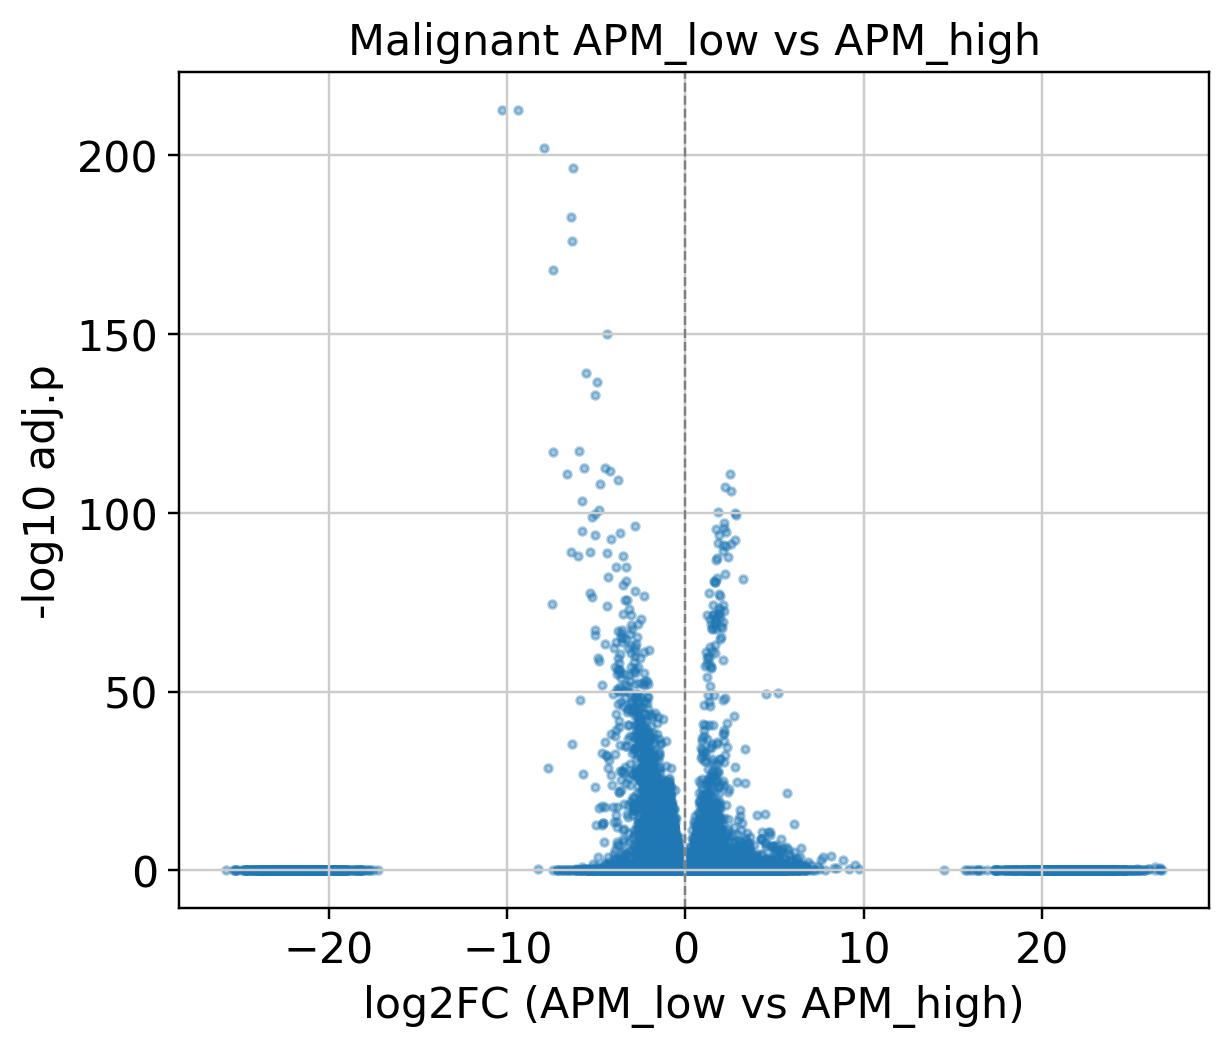

                    Term  Adjusted P-value
     Pancreas Beta Cells          0.760889
          Apical Surface          0.760889
              Complement          0.760889
     Allograft Rejection          0.760889
IL-6/JAK/STAT3 Signaling          0.760889
    Bile Acid Metabolism          0.760889
       KRAS Signaling Up          0.779800
       KRAS Signaling Dn          0.779800


In [12]:
mal_lh = mal[mal.obs["APM_stratum"].isin(["APM_low", "APM_high"])].copy()
mal_lh.obs["APM_stratum"] = mal_lh.obs["APM_stratum"].astype(str)
sc.tl.rank_genes_groups(mal_lh, "APM_stratum", groups=["APM_low"],
                        reference="APM_high", method="wilcoxon", use_raw=True)
de = sc.get.rank_genes_groups_df(mal_lh, group="APM_low")
print(de.head(15).to_string(index=False))

# Volcano
de["nlogp"] = -np.log10(de["pvals_adj"].clip(lower=1e-300))
plt.figure(figsize=(6, 5))
plt.scatter(de["logfoldchanges"], de["nlogp"], s=6, alpha=0.4)
plt.axvline(0, ls="--", c="grey", lw=0.8)
plt.xlabel("log2FC (APM_low vs APM_high)"); plt.ylabel("-log10 adj.p")
plt.title("Malignant APM_low vs APM_high"); plt.show()

# Enrichment on genes DOWN in APM-low (the silenced axis) via gseapy/Enrichr (needs internet)
try:
    import gseapy as gp
    down = de.sort_values("logfoldchanges").head(150)["names"].tolist()
    enr = gp.enrichr(gene_list=down, gene_sets=["MSigDB_Hallmark_2020"], outdir=None)
    print(enr.results[["Term", "Adjusted P-value"]].head(10).to_string(index=False))
except Exception as e:
    print("Enrichment skipped:", e)

## Phase 7 — Microenvironmental drivers (the core question)

Infer ligand–receptor communication from tumour-microenvironment senders (T, NK, myeloid, CAF,
endothelial) to malignant receivers, splitting the malignant compartment into APM-low and APM-high. The
IFN-γ → IFNGR axis is the built-in positive control (the canonical APM inducer); interactions
preferentially targeting APM-low cells become candidate **suppressive cues** for experimental follow-up.

In [13]:
# Build a combined label: TME types + malignant split by APM stratum
adata.obs["celltype_strat"] = adata.obs[ct_col].astype(str)
strat_map = mal.obs["APM_stratum"].astype(str)
mask = adata.obs_names.isin(strat_map.index)
adata.obs.loc[strat_map.index, "celltype_strat"] = ("Mal_" + strat_map).values
print(adata.obs["celltype_strat"].value_counts())

try:
    import liana as li
    li.mt.rank_aggregate(adata, groupby="celltype_strat",
                         expr_prop=0.1, use_raw=True, verbose=True)
    res = adata.uns["liana_res"]
    senders = [c for c in adata.obs["celltype_strat"].unique()
               if not str(c).startswith("Mal_")]
    li.pl.dotplot(adata, colour="lr_means", size="cellphone_pvals",
                  source_labels=senders,
                  target_labels=["Mal_low", "Mal_APM_low", "Mal_APM_high"],
                  top_n=25, orderby="lr_means", orderby_ascending=False)
except Exception as e:
    print("LIANA step requires the 'liana' package and internet for resources:", e)

celltype_strat
T.CD8           1759
T.CD4            856
B.cell           818
T.cell           706
Mal_APM_high     673
Mal_APM_low      673
Mal_APM_mid      672
Macrophage       420
?                307
CAF              106
Endo.            104
NK                92
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/usr/local/lib/python3.12/dist-packages/liana/method/_pipe_utils/_pre.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Generating ligand-receptor stats for 7186 samples and 1792 features


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/usr/local/lib/python3.12/dist-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:20<00:00, 48.09it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
LIANA step requires the 'liana' package and internet for resources: ['Mal_low'] not found in `liana_res['target']`!


## Phase 8 (cont.) — Summary Visualization: Differentially Expressed Genes

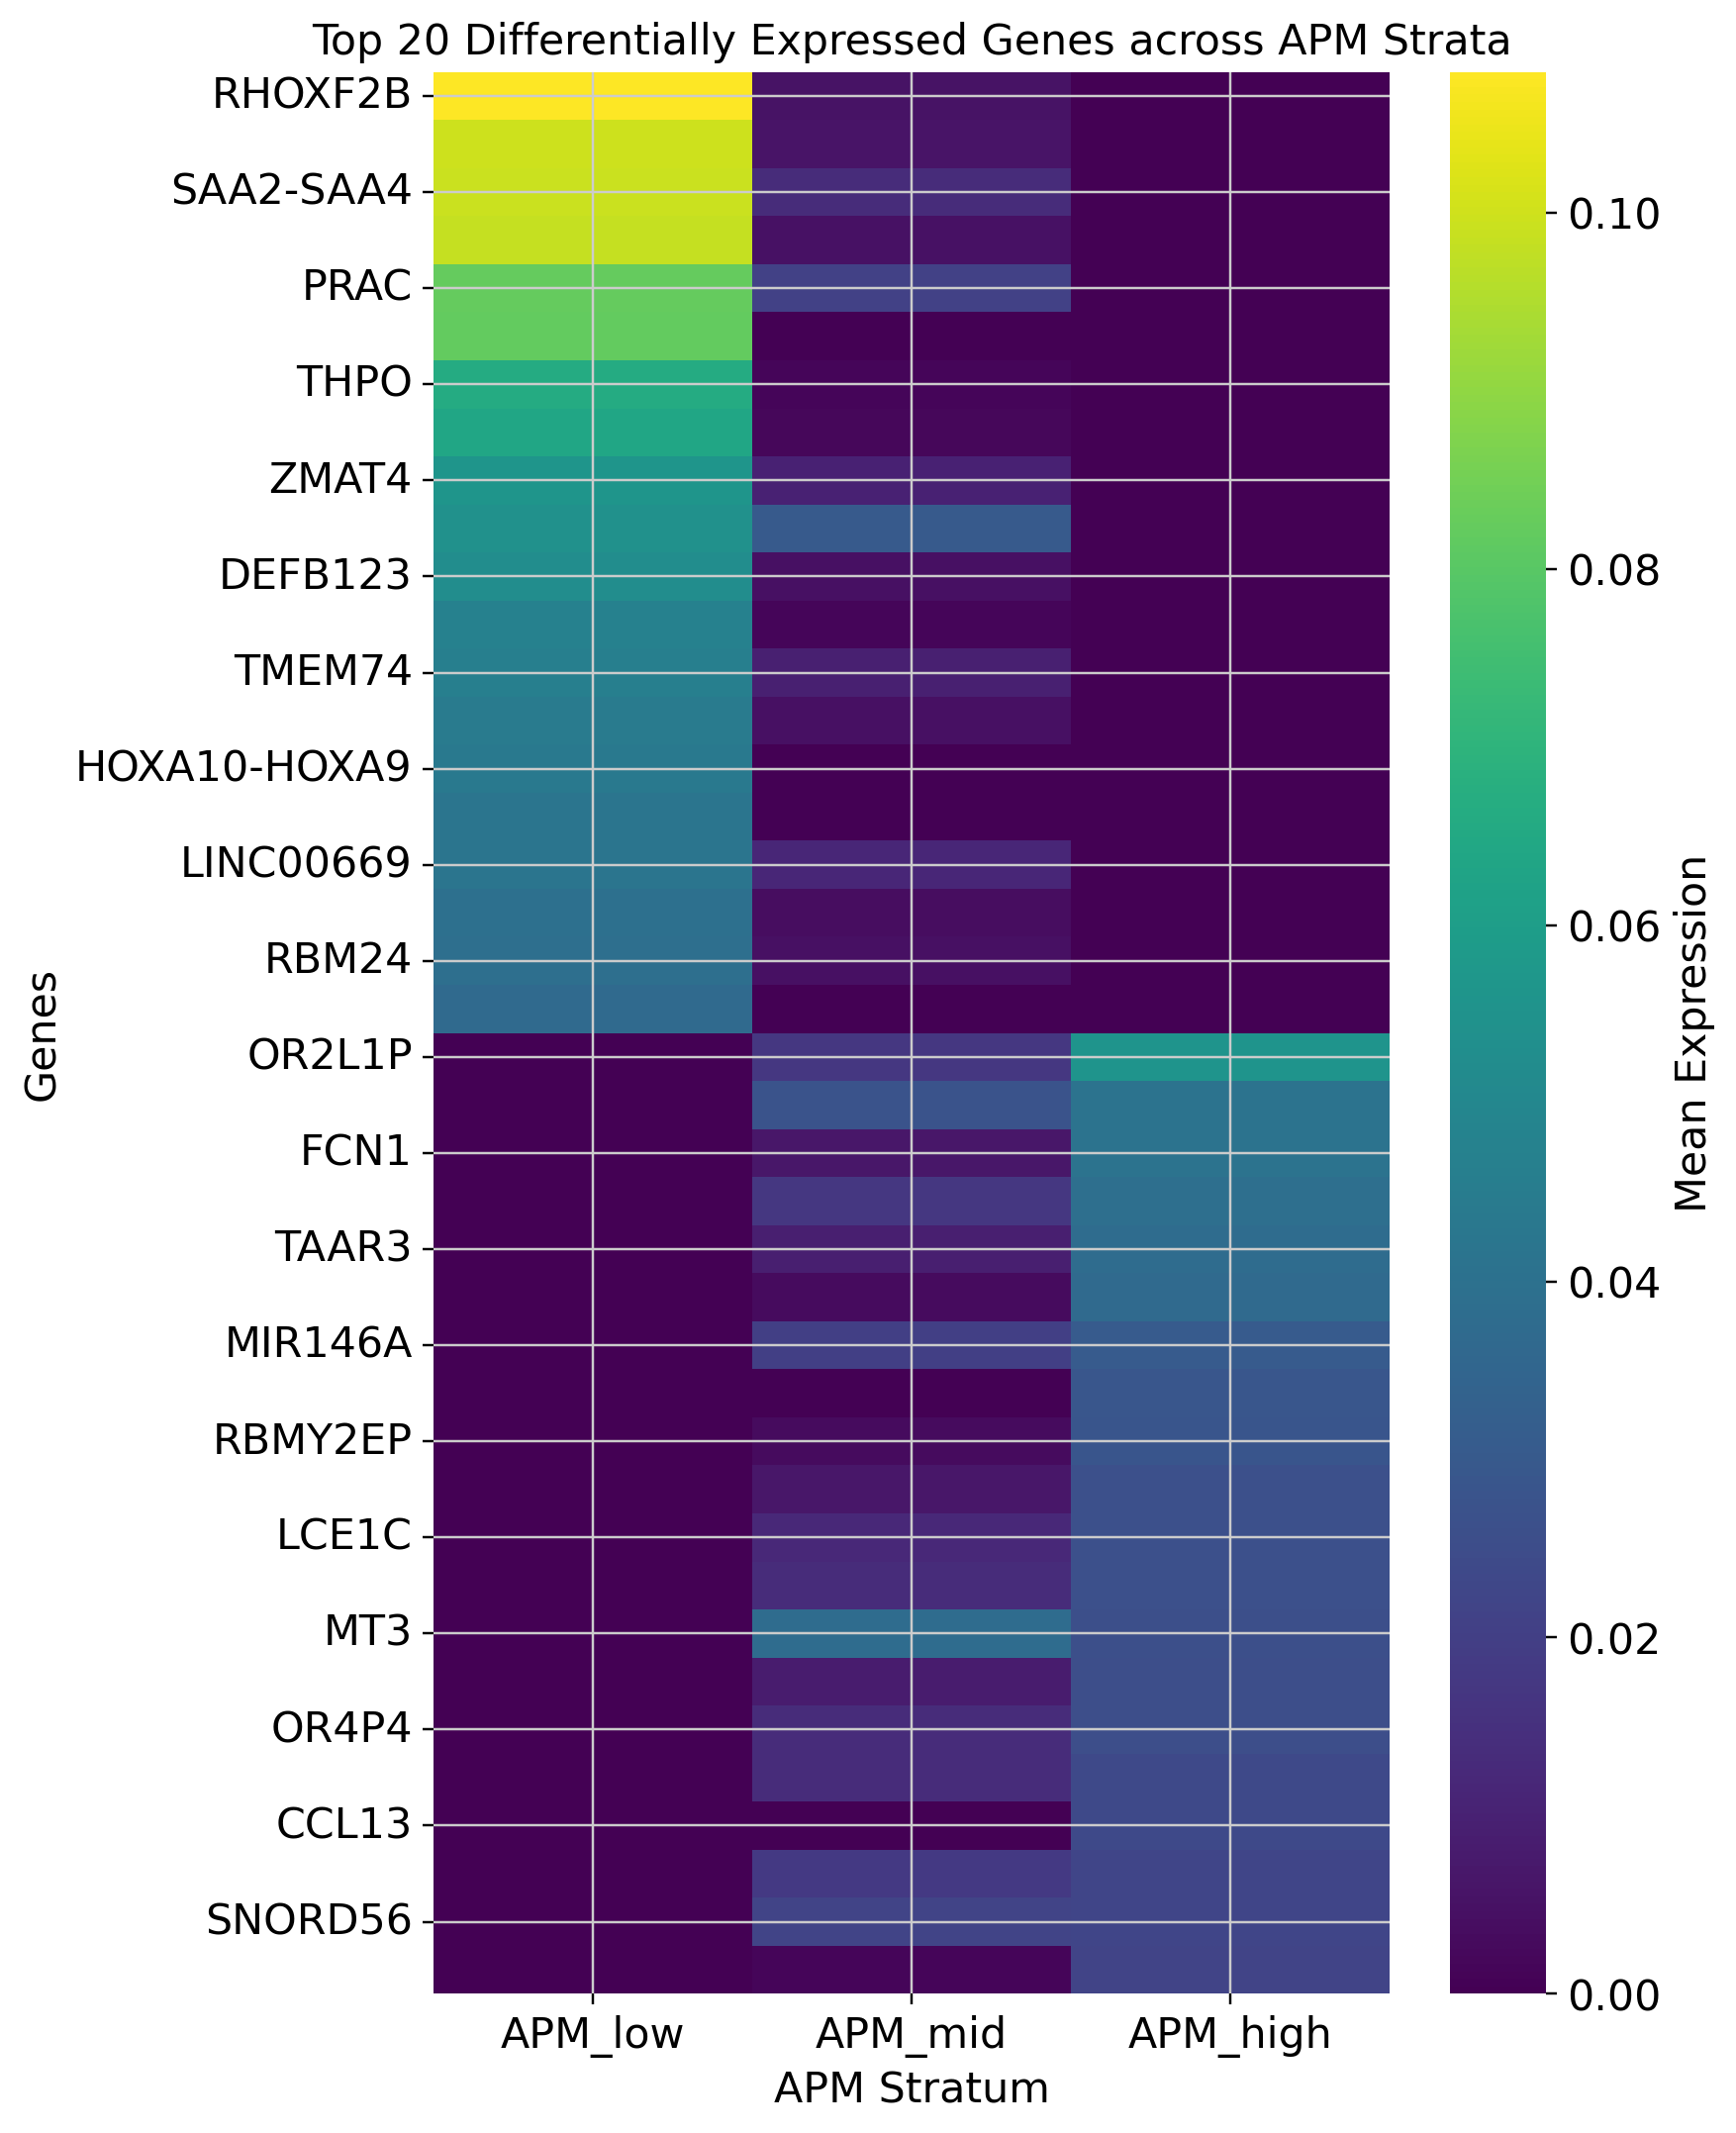

In [14]:
# Select top genes from differential expression analysis (up and down regulated)
top_n_genes = 20 # You can adjust this number

# Genes upregulated in APM_low (i.e., logfoldchanges > 0)
up_genes = de[de['logfoldchanges'] > 0].sort_values('logfoldchanges', ascending=False).head(top_n_genes)

# Genes downregulated in APM_low (i.e., logfoldchanges < 0)
down_genes = de[de['logfoldchanges'] < 0].sort_values('logfoldchanges', ascending=True).head(top_n_genes)

# Combine the top up and down regulated genes
selected_genes = pd.concat([up_genes, down_genes])['names'].tolist()

# Filter the AnnData object to include only the malignant cells and selected genes
# Ensure that the genes exist in the mal.raw.var_names before selecting
existing_selected_genes = [g for g in selected_genes if g in mal.raw.var_names]

if not existing_selected_genes:
    print("No selected genes found in the malignant cell data for heatmap.")
else:
    # Create a subset of `mal` with only the relevant genes for the heatmap
    mal_subset = mal[:, existing_selected_genes].copy()

    # Prepare data for the heatmap: mean expression for each stratum
    heatmap_data = pd.DataFrame(index=existing_selected_genes)
    for stratum in mal.obs['APM_stratum'].unique():
        stratum_cells = mal[mal.obs['APM_stratum'] == stratum]
        # Ensure that the raw data is used for gene expression
        # Use mal.raw.to_adata() to get an anndata object from raw counts
        # Then select the relevant cells and genes.
        # Or, directly access mal.raw.X if it's already aligned with mal.obs and mal.var
        # Assuming mal.raw is already aligned with mal.obs for cell indexing
        # and mal.raw.var_names for gene indexing

        # Get the expression values for the current stratum and selected genes
        # Need to handle potential misalignment between mal.var and mal.raw.var
        stratum_gene_expression = mal.raw[stratum_cells.obs_names, existing_selected_genes].X.mean(axis=0)
        heatmap_data[str(stratum)] = stratum_gene_expression.A1 if hasattr(stratum_gene_expression, 'A1') else stratum_gene_expression

    # Sort columns for consistent display (APM_low, APM_mid, APM_high)
    column_order = [s for s in ['APM_low', 'APM_mid', 'APM_high'] if s in heatmap_data.columns]
    heatmap_data = heatmap_data[column_order]

    # Plot the heatmap
    plt.figure(figsize=(8, 10))
    sns.heatmap(heatmap_data.loc[selected_genes].sort_values(by='APM_low', ascending=False), cmap='viridis', annot=False, fmt=".2f", cbar_kws={'label': 'Mean Expression'})
    plt.title(f'Top {top_n_genes} Differentially Expressed Genes across APM Strata')
    plt.ylabel('Genes')
    plt.xlabel('APM Stratum')
    plt.tight_layout()
    plt.show()

## Phase 9 — Spatial method transfer *(stretch / interview expansion)*

The scRNA-seq result nominates *who* talks to APM-low tumour cells; the spatial step asks *where* they
sit. With no multiplexed-imaging data in hand, this is a **method demonstration**: the same
neighbourhood / co-occurrence analysis (via `squidpy`) that would run on the lab's Phenocycler/CODEX
output, shown here on a public melanoma spatial sample. This mirrors the original report that the
resistance program marks immune-cold niches in situ.

```python
# Skeleton — run on a public melanoma spatial dataset (e.g. 10x Visium) with squidpy:
# import squidpy as sq
# sp = sc.read_h5ad("melanoma_spatial.h5ad")            # cells/spots with adata.obsm['spatial']
# sq.gr.spatial_neighbors(sp, coord_type="generic", n_neighs=6)
# sq.gr.nhood_enrichment(sp, cluster_key="celltype")    # immune vs APM-low tumour adjacency
# sq.pl.nhood_enrichment(sp, cluster_key="celltype")
# sq.gr.co_occurrence(sp, cluster_key="celltype")
```
Deliverable: a neighbourhood-enrichment heatmap testing whether the LIANA-nominated sender populations
are spatially adjacent to APM-low tumour regions.

## Phase 10 — Synthesis and mapping to the longitudinal workflow

**What this shows.** A reproducible pipeline that (1) scores HLA-I APM silencing per malignant cell,
(2) isolates an APM-low immune-evasive state, (3) characterises its transcriptional program, and
(4) nominates the microenvironmental signals associated with it — the question of which cues drive APM
silencing, in miniature.

**How it extends to longitudinal patient material.** The same scoring and stratification run per timepoint
across cryopreserved/FFPE series to track APM silencing over disease course and under ICB; the LIANA step
nominates drivers; the squidpy step localises them in Phenocycler data; nominated ligand–receptor pairs go
to ex vivo and CRISPR-based validation.




**Summary and Outlook**

This notebook provides a reproducible computational framework for investigating HLA-I APM silencing in melanoma at single-cell resolution. By leveraging publicly available data from the Jerby-Arnon et al. melanoma atlas, we demonstrated a structured workflow to:

Score and Stratify: Quantify APM activity in individual malignant cells and stratify them into APM-low, APM-mid, and APM-high groups.
Characterize: Uncover the transcriptional programs associated with APM-low cells, confirming their dedifferentiated and IFN-γ-blunted state.
Nominate Drivers: Infer potential microenvironmental ligand-receptor interactions preferentially directed towards APM-low malignant cells, thereby nominating candidate suppressive cues.
Conceptual Spatialization: Illustrate a transferable method for spatial analysis to contextualize findings within the tumor microenvironment.
Key Insights from this Demonstration:

The strong correlation between APM and IFN-γ response scores mechanistically links IFN-γ signaling with HLA-I APM expression.
APM-low malignant cells exhibit characteristics consistent with a dedifferentiated, immune-resistant phenotype.
Computational inference tools like liana can generate testable hypotheses regarding specific cell-cell communication pathways that may contribute to APM silencing.

**Key Insights from this Demonstration:**

*   The strong correlation between APM and IFN-γ response scores mechanistically links IFN-γ signaling with HLA-I APM expression.
*   APM-low malignant cells exhibit characteristics consistent with a dedifferentiated, immune-resistant phenotype.
*   Computational inference tools like `liana` can generate testable hypotheses regarding specific cell-cell communication pathways that may contribute to APM silencing.


**Future Directions and Outlook:**

This analytical pipeline can be readily extended to longitudinal patient cohorts and integrated with experimental validation studies:

*   **Longitudinal Analysis:** Apply the scoring and stratification methods to track APM silencing in patient samples over time (e.g., pre- and post-ICB treatment) to understand its dynamic regulation and clinical impact.
*   **Experimental Validation:** Prioritize and experimentally validate the `liana`-nominated ligand-receptor pairs in *in vitro* or *in vivo* models to confirm their causal role in APM silencing and immune evasion.
*   **Integrated Spatial Multi-omics:** When paired with multiplexed imaging data (e.g., Phenocycler, CODEX), the `squidpy` component can be fully utilized to spatially map APM-low regions and their cellular neighborhoods, providing critical contextual information.
*   **Targeted Therapies:** Insights gained from this framework could inform the development of novel therapeutic strategies aimed at reversing APM silencing, thereby restoring anti-tumor immunity and improving responses to immunotherapy.

Ultimately, this reproducible and extendable workflow serves as a powerful tool for dissecting complex immune evasion mechanisms in cancer and accelerating the translation of basic research findings into clinical impact.

**Candidate hypotheses (falsifiable).**
1. APM-low malignant cells are enriched for a dedifferentiated/IFN-blunted state and depleted for IFN-γ
   response relative to APM-high cells.
2. Specific myeloid/CAF-derived ligands (e.g. TGF-β-family) are preferentially directed at APM-low cells.
3. APM-low tumour regions are spatially segregated into immune-cold niches with reduced CD8⁺ T-cell
   adjacency.



---
### References
- Jerby-Arnon L, *et al.* A cancer cell program promotes T cell exclusion and resistance to checkpoint
  blockade. *Cell* 175:984–997 (2018). doi:10.1016/j.cell.2018.09.006 — GEO GSE115978.
- Tirosh I, *et al.* Dissecting the multicellular ecosystem of metastatic melanoma by single-cell RNA-seq.
  *Science* 352:189–196 (2016). GEO GSE72056.
- Sade-Feldman M, *et al.* Defining T cell states associated with response to checkpoint immunotherapy in
  melanoma. *Cell* 175:998–1013 (2018). GEO GSE120575.
- Paschen and colleagues — transcriptional silencing of the HLA-I APM as a route to ICB resistance
  (J Clin Invest 2020; and reviews on APM regulation in melanoma).
- Dimitrov D, *et al.* LIANA: comparison and consensus of cell–cell communication methods. *Nat Commun* (2022).


